# Parameteridentification 

Zunächst wird die Pendeldistanz über die Pendelgleichung bestimmt. 



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks, savgol_filter

############## gegebene Parameter ###############
g = 9.81
L2 = 0.240
lP = 0.1917
mS = 0.0274
mP = 0.0510         # <- 0.0 wenn keine Zusatzmasse montiert ist
m2 = mS + mP
l2 = L2/2
epsilon = 0.01
mu_V2 = 1.332e-5 # Referenz Reibungsparameter Pendel
mu_H2 = 3.018e-4 # Referenz Reibungsparameter Pendel
epsilon = 0.01

############## Daten einlesen und richtig zuschneiden ################
# CSV einlesen für Pendelmasse
df = pd.read_csv("messungIdentPendulum.csv")
# Die beiden Daten werden für die Pendelidentifikation verwendet
t = df["time"].values
theta2 = df["F: theta2"].values
# Daten nochmal neu laden um sie dann für die Reibungs-Parameteridentifikation zuschneiden zu können 
theta2_meas = df["F: theta2"].values
dtheta2_meas = df["F: theta2dot"].values
# Zeitfenster/zuschneiden, da im unteren Teil das Model der Haftreibung nicht akurat ist
mask = (t >= 5) & (t <= 20)
t_mask = t[mask]
theta2_meas = theta2_meas[mask]
dtheta2_meas = dtheta2_meas[mask]
# Daten für die Simulation nochmal separat - auch zum zuschneiden
t_m = df["time"].values
theta2_m = df["F: theta2"].values 
t_m = t_m[210:] # optional 0 Werte schneiden
theta2_m = theta2_m[210:] # optional 0 Werte schneiden


# Startwert für die Simulation
x0 = [-0.27724555167930104, 0.3187903256803709]  # Startwerte nur theta2, theta2dot fürs reduzierte Pendel model (genommen aus 210 Tabelle)
# Simulationszeitraum
t_span = (0.0, 37.0)

Dann wird die Pendeldistanz über die Pendelgleichung bestimmt. 
Dafür werden zunächst die Peaks bestimmt, und über diese dann die Eigenfrequenz des Pendels. 
Aus der linearisierten Pendelgleichung (Rotor fixiert)

$$
J_2\,\ddot{\theta}_2 + m_2 l_2 g\,\theta_2 = 0
$$

folgt für die Eigenkreisfrequenz

$$
\omega^2 = \frac{m_2 l_2 g}{J_2}.
$$

Mit  
$$
m_2 l_2 = m_S\frac{L_2}{2} + m_P l_P,
\qquad
J_2 = \frac{1}{3} m_S L_2^2 + m_P l_P^2
$$

ergibt sich die Gleichung

$$
\omega^2\left(\frac{1}{3} m_S L_2^2 + m_P l_P^2\right)
=
g\left(m_S\frac{L_2}{2} + m_P l_P\right).
$$

Umgestellt erhält man eine quadratische Gleichung in \(l_P\):

$$
m_P \omega^2\, l_P^2
- m_P g\, l_P
+ \left(\frac{1}{3} m_S L_2^2 \omega^2 - m_S g \frac{L_2}{2}\right)
= 0.
$$

Mit der Mitternachtsformel folgt schließlich

$$
l_P
=
\frac{m_P g
\pm
\sqrt{(m_P g)^2
-4 m_P \omega^2
\left(\frac{1}{3} m_S L_2^2 \omega^2 - m_S g \frac{L_2}{2}\right)}}
{2 m_P \omega^2}.
$$


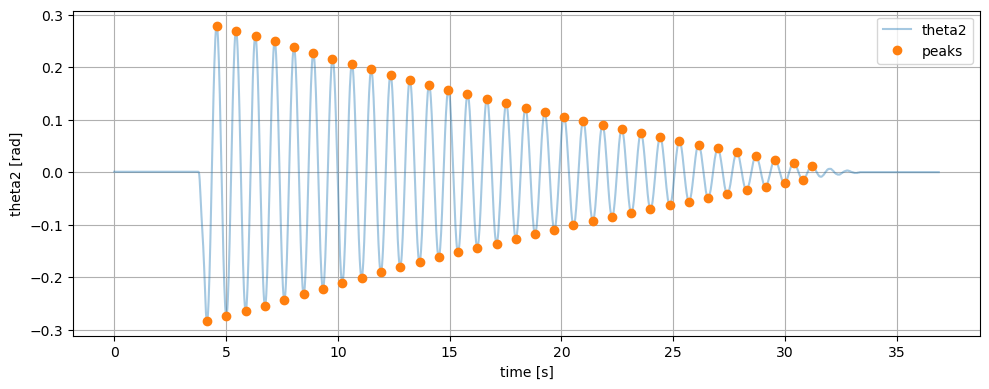

lP gefunden! lP = 0.191605 m


In [2]:
# --- Pendellänge lP aus Eigenfrequenz ---

def estimate_omega_from_peaks(t, theta2, plot=True):
    t = np.asarray(t).ravel()          # in 1D-NumPy-Array umwandeln
    x = np.asarray(theta2).ravel()     
    
    m = np.isfinite(t) & np.isfinite(x)  # Maske: nur endliche (keine NaN/Inf) Werte behalten
    t, x = t[m], x[m]                   # Ungültige Werte entfernen
    idx = np.argsort(t)                 # Sortierindizes nach aufsteigender Zeit berechnen
    t, x = t[idx], x[idx]               # Zeit und Signal entsprechend sortieren

    dt = float(np.median(np.diff(t)))   # Typische Abtastzeit als Median der Zeitdifferenzen
    x = x - np.median(x)                # DC-Offset entfernen (Signal um Median zentrieren)

    win = int(round(0.2 / dt))          # Fensterlänge ≈ 0.2 Sekunden (in Samples)
    win = max(11, win) | 1              # Mindestens 11 Punkte, durch |1 ungerade erzwingen
    x_s = savgol_filter(x, window_length=win, polyorder=3)  # Savitzky-Golay-Glättung (Polynomgrad 3)

    amp_ref = np.percentile(np.abs(x_s), 90)  # Typische Signalamplitude (90%-Quantil)
    prom = max(0.10 * amp_ref, 1e-9)          # Mindest-Prominenz: 10% der Amplitude (robust gegen Rauschen)

    # positive + negative Peaks finden → Abstand entspricht halber Periode
    peaks = np.sort(np.r_[find_peaks(x_s, prominence=prom)[0],      # Maxima
                         find_peaks(-x_s, prominence=prom)[0]])     # Minima (über Spiegelung)
    if peaks.size < 6:                      # Mindestens 6 Peaks erforderlich
        raise RuntimeError(f"Zu wenige Peaks ({peaks.size}).")

    dT = np.diff(t[peaks])                  # Zeitabstände zwischen aufeinanderfolgenden Peaks
    med = np.median(dT)                     # Typischer Peak-Abstand (Median)
    dT = dT[(dT > 0.5*med) & (dT < 1.5*med)]  # Ausreißer entfernen (nur plausible Abstände behalten)
    if dT.size < 4:                         # Genug konsistente Abstände notwendig
        raise RuntimeError("Peak abstand inkonsistent")

    T = 2.0 * float(np.mean(dT))            # Da Peaks halbe Periode → mit 2 multiplizieren
    omega = 2.0 * np.pi / T                 # Kreisfrequenz ω = 2π / T

    if plot:
        plt.figure(figsize=(10, 4))         
        plt.plot(t, x, label="theta2", alpha=0.4)  
        #plt.plot(t, x_s, label="theta2 (geglättet)")  # Optional: geglättetes Signal
        plt.plot(t[peaks], x_s[peaks], "o", label="peaks")  # Erkannte Peaks markieren
        plt.grid(True); plt.xlabel("time [s]"); plt.ylabel("theta2 [rad]")
        plt.legend(); plt.tight_layout(); plt.show()

    return omega                            # Geschätzte Kreisfrequenz zurückgeben

omega = estimate_omega_from_peaks(t, theta2, plot=True)

# Mitternachtsformel für lP 
a = mP * omega**2
bq = -mP * g
c = (1/3) * mS * L2**2 * omega**2 - mS * g * (L2 / 2)

D = bq**2 - 4*a*c             # checken ob Wurzel negativ
if D < 0:
    raise ValueError("Keine reelle Lösung für lP (Diskriminante < 0)")

# nullstellen finden
lP_1 = (-bq + np.sqrt(D)) / (2*a)
lP_2 = (-bq - np.sqrt(D)) / (2*a)
lP_candidates = [l for l in (lP_1, lP_2) if 0 < l < L2]
if not lP_candidates:
    raise ValueError("Keine physikalisch sinnvolle Lösung gefunden")

lP_ident = lP_candidates[0]
print(f"lP gefunden! lP = {lP_ident:.6f} m")

# neues J2_hat berechnen:
J2_hat = (1/12) * mS * L2**2 + mS * (L2/2)**2 + mP * lP_ident**2    

In [3]:
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

# ==============================
# neues l2_eff mit lP_ident berechnen
# ==============================
l2_eff = (mS * l2 + mP * lP_ident) / m2   
dt = float(np.median(np.diff(t_mask)))    # typische Abtastzeit (Median ist robust gegen Ausreißer)

# ==============================
# Reibung 
# ==============================
def friction_spec(v, mu_V, mu_H, eps=epsilon):
    if v <= -eps:
        return mu_V * v - mu_H           
    if v >= eps:
        return mu_V * v + mu_H           
    return ((3.0*mu_H)/(2.0*eps) + 0.5*mu_V) * v - (mu_H/(2.0*eps**3)) * (v**3)

# ==============================
# ODE: Rotor fix, linearisierte Gravitation (sin(theta)≈theta)
# x = [theta2, dtheta2]
# ==============================
def pendulum_ode(t_, y, mu_V2, mu_H2):
    theta, dtheta = y                               
    b = friction_spec(dtheta, mu_V2, mu_H2, epsilon)
    
    ddtheta = -(m2 * l2_eff * g * theta + b) / J2_hat
    return [dtheta, ddtheta]                        

# ==============================
# Residuen für least_squares
# p = [mu_V2, mu_H2]
# ==============================
def residuals(p):
    mu_V2, mu_H2 = p                     # aktuelle Parameterschätzung entpacken

    # Anfangszustand für Simulation = erster Messwert
    y0 = [float(theta2_meas[0]), float(dtheta2_meas[0])]

    # Simulation des Modells mit aktuellen Parametern
    sol = solve_ivp(
        pendulum_ode,                    
        (float(t_mask[0]), float(t_mask[-1])),  # Simulationszeitraum
        y0,                              # Anfangszustand
        args=(mu_V2, mu_H2),             # zu optimierende Parameter an ODE übergeben
        t_eval=t_mask,                  
        method="RK45",                   
        rtol=1e-7,                       
        atol=1e-9,                       
        max_step=dt,                     
    )

    theta_sim = sol.y[0]                 # simulierte Winkelwerte
    dtheta_sim = sol.y[1]                # simulierte Winkelgeschwindigkeit

    # Gewichtung für Geschwindigkeitsfehler (z.B. kleiner wählen bei starkem Rauschen)
    w_dtheta = 1.0

    # Residualvektor:
    # least_squares minimiert 0.5 * ||r||^2
    # Hier: Fehler zwischen Simulation und Messung für alle Zeitpunkte
    return np.concatenate([
        theta_sim - theta2_meas,                 # Fehler im Winkel
        w_dtheta * (dtheta_sim - dtheta2_meas),  # (gewichteter) Fehler in der Geschwindigkeit
    ])

# ==============================
# Startwerte + Bounds (physikalisch: mu>=0)
# ==============================
p0 = np.array([1.332e-5, 3.018e-4])    # Startwerte für [mu_V2, mu_H2]
lb = np.array([0.0, 0.0])             # untere Schranken (keine negative Reibung)
ub = np.array([1e-2, 1e-1])           # obere Schranken (physikalisch plausible Größenordnung)

# Least-Squares-Optimierung:
# Minimiert 0.5 * ||residuals(p)||^2
res = least_squares(residuals, p0, bounds=(lb, ub), method="trf")

mu_V2_opt, mu_H2_opt = res.x          # optimale Parameter auslesen

print("Optimierte Parameter:")
print(f"mu_V2 = {mu_V2_opt:.6e}")
print(f"mu_H2 = {mu_H2_opt:.6e}")
print("success:", res.success, "-", res.message)  # Status der Optimierung
print("cost:", res.cost, "(= 0.5*||r||^2)")       # Zielfunktionswert

Optimierte Parameter:
mu_V2 = 1.511717e-04
mu_H2 = 1.817986e-04
success: True - `xtol` termination condition is satisfied.
cost: 18.30011073373524 (= 0.5*||r||^2)


# Simulation Vergleich

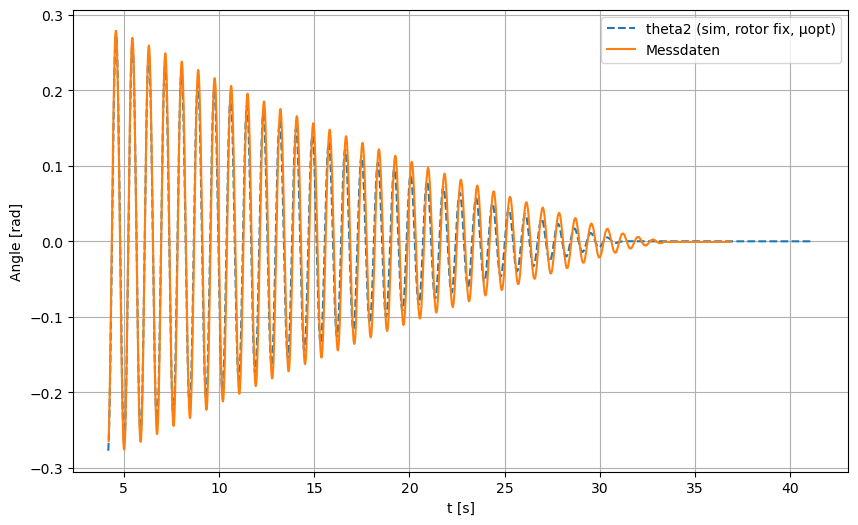

In [4]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd
# Schwerpunkt des Gesamtsystems (Stab + Zusatzmasse)
lS = L2 / 2.0
l2_eff = (mS * lS + mP * lP) / m2



# ==========================================================
# Reibung: Wie aus der Angabe
# ==========================================================
def friction(v: float, mu_V: float, mu_H: float) -> float:
    if v <= -epsilon:
        return mu_V * v - mu_H
    if v >= epsilon:
        return mu_V * v + mu_H
    c1 = 3.0 * mu_H / (2.0 * epsilon) + 0.5 * mu_V
    c3 = -mu_H / (2.0 * epsilon**3)
    return c3 * v**3 + c1 * v

# ==========================================================
# Pendel-Zustandsraummodell (Rotor fix)
# x = [theta2, theta2_dot]
# ==========================================================
def pendulum_dynamics(t, x):
    theta2, theta2_dot = x
    b2 = friction(theta2_dot, mu_V2, mu_H2)
    grav = (m2 * l2_eff * g) * (theta2)
    # J2 mit lp
    J2_hat = (1.0/3.0) * mS * L2**2 + mP * lP**2
    theta2_ddot = -(grav + b2) / J2_hat
    return [theta2_dot, theta2_ddot]

# zweite funktion nur um das berechnete lp zu berücksichtigen
def pendulum_dynamics2(t, x):
    theta2, theta2_dot = x
    b2 = friction(theta2_dot, mu_V2, mu_H2)
    # J2 mit lp_ident
    J2_hat = (1.0/3.0) * mS * L2**2 + mP * lP_ident**2
    grav = (m2 * l2_eff * g) * (theta2)
    theta2_ddot = -(grav + b2) / J2_hat
    return [theta2_dot, theta2_ddot]


# ==========================================================
# Simulation
# ==========================================================
# Erste Simulation mit Reibwerten aus der Angabe
sol1 = solve_ivp(
    pendulum_dynamics,
    t_span,
    x0,
    rtol=1e-6,
    atol=1e-9,
    max_step=1e-2,
)

# zweite Simulation mit math. opt. bestimmten Reibwerten
mu_V2 = mu_V2_opt
mu_H2 = mu_H2_opt
sol2 = solve_ivp(
    pendulum_dynamics2,     # Funktion von der die Ableitung berechnet werden soll
    t_span,                # Integrationsbereich
    x0,                    # Anfangszustand
    rtol=1e-6,             # relative Toleranz
    atol=1e-9,             # absolute Toleranz
    max_step=1e-2          # Schrittweite des adaptiven Solvers
)


plt.figure(figsize=(10, 6))
#plt.plot(sol1.t + 4.18, sol1.y[0], label="theta2 (sim, rotor fix)")
plt.plot(sol2.t + 4.18, sol2.y[0],"--", label="theta2 (sim, rotor fix, µopt)")
plt.plot(t_m , theta2_m, label="Messdaten")
plt.ylabel("Angle [rad]")
plt.xlabel("t [s]")
plt.legend()
plt.grid(True)
plt.show()


# Versuch ala Vorlesung - geht nicht

In [5]:

###################################
# Bestimmung Reibungskooeffzienten ala Vorlesung
###################################

# ==============================
# CSV einlesen
# ==============================
df = pd.read_csv("messungIdentPendulum.csv")
t = df["time"].values
theta2 = df["F: theta2"].values
theta2dot = df["F: theta2dot"].values
dt = t[1] - t[0]
print("dt ist", dt)
# ==============================
# Diskrete Ableitungen
# ==============================
theta2 = theta2[200:-1000] # thetas stimmen alle - händisch nachgerechnet (startet bei 201) gekürzt um den flachen Teil der Daten zu kürzen
theta2_k = theta2[:-1]
theta2_k_length = len(theta2_k)
#print("length theta2_k =", theta2_k_length)

theta2dot = theta2dot[200:-1000]
theta2dot_k = theta2dot[:-1]
theta2dot_k_length = len(theta2dot_k)
#print("length theta2dot_k =", theta2dot_k_length)

theta2ddot = (theta2dot[1:] - theta2dot[:-1]) / dt
theta2ddot_k = theta2ddot
theta2ddot_k_length = len(theta2ddot_k)
N = theta2ddot_k_length
#print("length theta2ddot_k =", N)
#print("theta2dot", theta2dot_k)
#print("theta2ddot", theta2ddot_k)
# ==============================
# Regressionsmatrix aufbauen
# ==============================
A = np.zeros((N, 2))
b = np.zeros(N)

for k in range(N):
    A[k, 0] = theta2dot_k[k]
    A[k, 1] = np.sign(theta2dot_k[k])#np.tanh(theta2dot_k[k]/epsilon)

    b[k] = - (g * (mS * l2 + mP * lP_ident) * theta2_k[k]) - (J2_hat * theta2ddot_k[k])   # m2 kürzt sich im linken teil
#print(A)
#print(b)
theta = np.linalg.solve(A.T @ A, A.T @ b)
print(f"µ_V ist: {theta[0]:.6e}")
print(f"µ_H ist: {theta[1]:.6e}")

dt ist 0.02
µ_V ist: 1.820375e-04
µ_H ist: -3.811826e-04
